<a href="https://colab.research.google.com/github/Yasser-Raouf/6th_Project/blob/main/TCR%26RQD.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
print(torch.cuda.is_available())

True


In [ ]:
!pip install ultralytics opencv-python matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 26.2 MB/s eta 0:00:00


(np.float64(-0.5), np.float64(719.5), np.float64(1034.5), np.float64(-0.5))

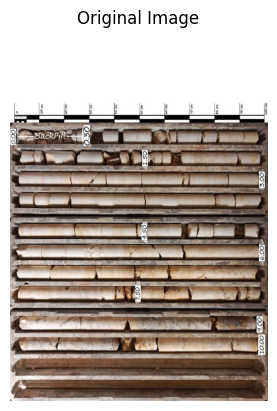

In [ ]:
import cv2
import matplotlib.pyplot as plt

img = cv2.imread("Picture1.jpg")

plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("Original Image")
plt.axis('off')

In [ ]:
#Here we gonna preprocessing tha image

(np.float64(-0.5), np.float64(899.5), np.float64(599.5), np.float64(-0.5))

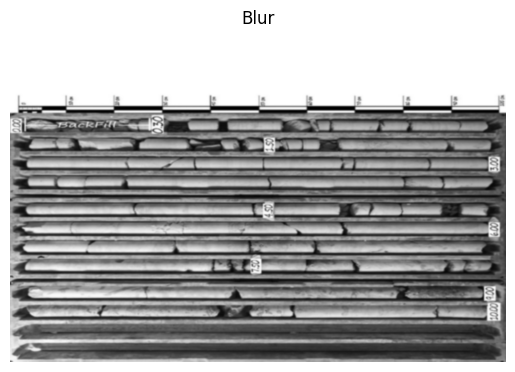

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread("Picture1.jpg")
img = cv2.resize(img, (900, 600))

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
blur = cv2.GaussianBlur(gray, (5,5), 0)

plt.imshow(blur, cmap='gray')
plt.title("Blur")
plt.axis('off')

(np.float64(-0.5), np.float64(899.5), np.float64(599.5), np.float64(-0.5))

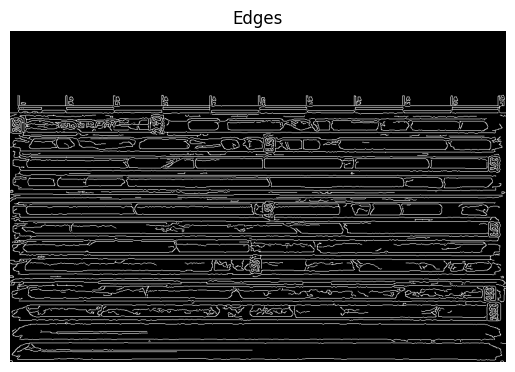

In [ ]:
edges = cv2.Canny(blur, 50, 150)

plt.imshow(edges, cmap='gray')
plt.title("Edges")
plt.axis('off')

(np.float64(-0.5), np.float64(899.5), np.float64(599.5), np.float64(-0.5))

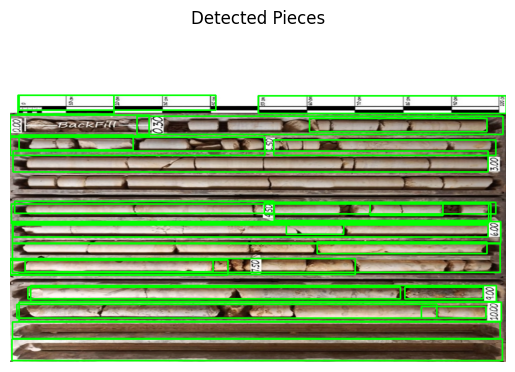

In [ ]:
contours, _ = cv2.findContours(edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

img_detect = img.copy()

boxes = []

for cnt in contours:
    x, y, w, h = cv2.boundingRect(cnt)

    if w > 50 and h > 20:
        boxes.append((x,y,w,h))
        cv2.rectangle(img_detect, (x,y), (x+w,y+h), (0,255,0), 2)

plt.imshow(cv2.cvtColor(img_detect, cv2.COLOR_BGR2RGB))
plt.title("Detected Pieces")
plt.axis('off')

In [ ]:
# Here we have some noise

Text(0.5, 1.0, 'Horizontal Projection')

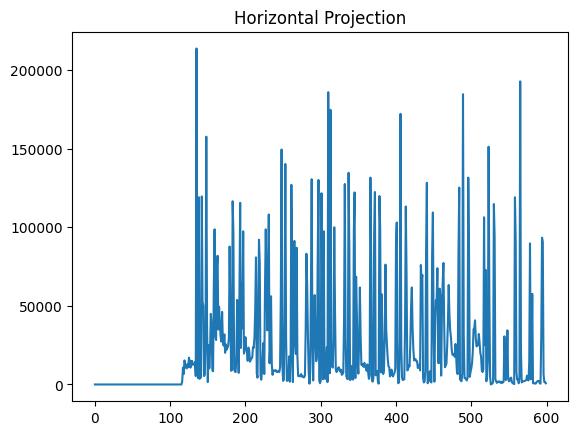

In [ ]:
horizontal_projection = np.sum(edges, axis=1)

plt.plot(horizontal_projection)
plt.title("Horizontal Projection")

Text(0.5, 1.0, 'Smoothed Projection')

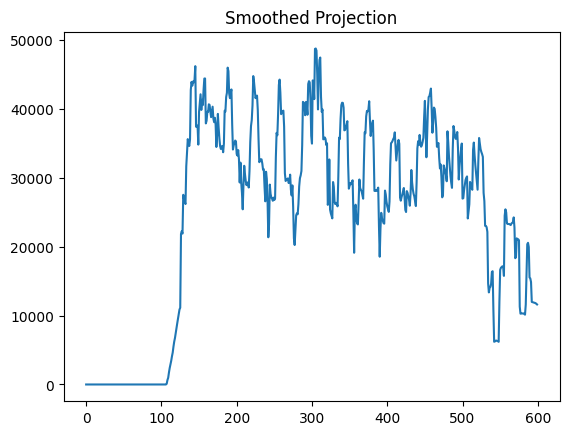

In [ ]:
import numpy as np

smooth = np.convolve(horizontal_projection, np.ones(20)/20, mode='same')

plt.plot(smooth)
plt.title("Smoothed Projection")

In [ ]:
from scipy.signal import find_peaks

peaks, _ = find_peaks(smooth, distance=40, height=50000)

print(peaks)

[]


In [ ]:
peaks, _ = find_peaks(smooth, distance=40, height=25000)
print(peaks)
print(np.max(smooth))

[145 188 257 305 376 458 522]
48717.75


(np.float64(-0.5), np.float64(899.5), np.float64(599.5), np.float64(-0.5))

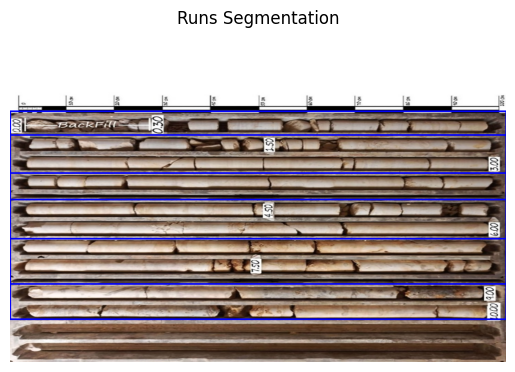

In [ ]:
img_runs = img.copy()

for (start, end) in runs:
    cv2.rectangle(img_runs, (0, start), (img.shape[1], end), (255,0,0), 2)

plt.imshow(cv2.cvtColor(img_runs, cv2.COLOR_BGR2RGB))
plt.title("Runs Segmentation")
plt.axis('off')

In [ ]:
pixels_per_cm = img.shape[1] / 150

NameError: name 'img' is not defined

In [ ]:
run_results = []

for (start, end) in runs:
    run_pieces = []

    for (x,y,w,h) in boxes:
        if start <= y <= end:
            run_pieces.append((x,y,w,h))

    run_results.append(run_pieces)

In [ ]:
import cv2

img = cv2.imread("Picture1.jpg")
img = cv2.resize(img, (900, 600))

pixels_per_cm = img.shape[1] / 150

print("pixels_per_cm:", pixels_per_cm)

pixels_per_cm: 6.0


In [ ]:
filtered_boxes = []

for (x,y,w,h) in boxes:
    keep = True
    for (x2,y2,w2,h2) in filtered_boxes:

        if x >= x2 and y >= y2 and x+w <= x2+w2 and y+h <= y2+h2:
            keep = False
            break
    if keep:
        filtered_boxes.append((x,y,w,h))

boxes = filtered_boxes

In [ ]:
all_results = []

for run in run_results:

    if len(run) == 0:
        continue

    lengths_cm = [w / pixels_per_cm for (x,y,w,h) in run]

    total = min(sum(lengths_cm), 150)

    rqd = sum([l for l in lengths_cm if l >= 20 and l < 80])
    rqd = min(rqd, total)

    TCR = (total / 150) * 100
    RQD = (rqd / 150) * 100

    all_results.append((TCR, RQD))

for i, (tcr, rqd) in enumerate(all_results):
    print(f"Run {i}: TCR={tcr:.2f}%, RQD={rqd:.2f}%")

Run 0: TCR=86.78%, RQD=86.78%
Run 1: TCR=100.00%, RQD=100.00%
Run 2: TCR=99.00%, RQD=99.00%
Run 3: TCR=58.33%, RQD=58.33%
Run 4: TCR=100.00%, RQD=100.00%
Run 5: TCR=28.78%, RQD=15.78%


In [ ]:
def split_piece(img, x, y, w, h):
    piece = img[y:y+h, x:x+w]

    gray = cv2.cvtColor(piece, cv2.COLOR_BGR2GRAY)

    # projection عمودي
    vertical_proj = np.sum(gray, axis=0)

    # smoothing
    smooth = np.convolve(vertical_proj, np.ones(10)/10, mode='same')

    # detect gaps (fractures)
    gaps, _ = find_peaks(-smooth, distance=20)

    segments = []
    prev = 0

    for g in gaps:
        segments.append(g - prev)
        prev = g

    segments.append(w - prev)

    return segments


In [ ]:
lengths_cm = []

for (x,y,w,h) in run:
    segments = split_piece(img, x, y, w, h)

    for seg in segments:
        length_cm = seg / pixels_per_cm
        lengths_cm.append(length_cm)

In [ ]:
for (x,y,w,h) in run:
    segments = split_piece(img, x, y, w, h)

    print("Segments:", segments[:5])

    for seg in segments:
        length_cm = seg / pixels_per_cm
        lengths_cm.append(length_cm)

In [ ]:
for (x,y,w,h) in run[:1]:
    segments = split_piece(img, x, y, w, h)
    print("Example segments:", segments)

In [ ]:
"""
TCR / RQD Pipeline — v3 with Debug Mode
=========================================
Run with:  python tcr_rqd_v3.py --debug        (saves debug images)
           python tcr_rqd_v3.py                 (results only)
           python tcr_rqd_v3.py --calibrate     (prints tray width estimates)
"""

import cv2
import numpy as np
from scipy.signal import find_peaks
import os, argparse

# ─────────────────────────────────────────────────────────────────
# CONFIGURATION  ← tune these if results are wrong
# ─────────────────────────────────────────────────────────────────
RUN_LENGTH_CM      = 150      # Each core run = 1.5 m
RQD_MIN_CM         = 10       # Standard geotechnical threshold
RESIZE_W           = 1200     # Wider = better resolution for small pieces
RESIZE_H           = 900

# Tray width calibration
# Option A (auto):   set TRAY_WIDTH_PX = None  → pipeline estimates it
# Option B (manual): set TRAY_WIDTH_PX = <integer>  → use fixed value
#   To find the right value: run with --debug, open debug_Picture1.jpg,
#   measure the pixel distance between the inner left and right tray walls.
TRAY_WIDTH_PX      = None     # e.g. set to 980 after calibrating

# Piece detection filters (in pixels, after resize to RESIZE_W x RESIZE_H)
MIN_PIECE_W        = 25       # ignore tiny fragments
MAX_PIECE_W_RATIO  = 0.50     # ignore anything wider than 50% of image (labels, rows)
MIN_PIECE_H        = 12
MAX_PIECE_H        = 160

# Run detection
MIN_RUNS           = 2
MAX_RUNS           = 10
# ─────────────────────────────────────────────────────────────────


def estimate_tray_width(img, debug=False):
    """
    Estimate tray interior width in pixels.
    Strategy: look at a horizontal band in the MIDDLE of the image,
    find the dominant left and right vertical edges.
    """
    h, w = img.shape[:2]

    y1, y2 = int(h * 0.30), int(h * 0.70)
    strip  = img[y1:y2, :]

    gray       = cv2.cvtColor(strip, cv2.COLOR_BGR2GRAY)
    sobelx     = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=5)
    col_energy = np.sum(np.abs(sobelx), axis=0)
    smooth     = np.convolve(col_energy, np.ones(15) / 15, mode='same')

    peaks, _ = find_peaks(
        smooth,
        distance=w // 5,
        height=np.max(smooth) * 0.25,
        prominence=np.max(smooth) * 0.10
    )

    if debug:
        print(f"  [calibrate] image width={w}px, detected wall peaks at x={peaks}")

    if len(peaks) >= 2:
        left_wall  = peaks[0]
        right_wall = peaks[-1]
        if (right_wall - left_wall) > w * 0.40:
            tray_w = right_wall - left_wall
            if debug:
                print(f"  [calibrate] tray width estimated: {tray_w}px "
                      f"(left={left_wall}, right={right_wall})")
            return tray_w, left_wall, right_wall

    fallback = int(w * 0.75)
    margin   = (w - fallback) // 2
    if debug:
        print(f"  [calibrate] wall detection failed, using fallback: {fallback}px")
    return fallback, margin, margin + fallback


def detect_runs(edges, img_h, debug=False):
    """
    Detect horizontal run bands using valley-finding on edge projection.
    """
    h_proj = np.sum(edges, axis=1).astype(float)
    smooth = np.convolve(h_proj, np.ones(40) / 40, mode='same')

    inv_smooth = np.max(smooth) - smooth
    valleys, _ = find_peaks(
        inv_smooth,
        distance=img_h // (MAX_RUNS + 2),
        prominence=np.max(inv_smooth) * 0.10
    )

    boundaries = np.sort(np.concatenate([[0], valleys, [img_h]]))
    runs = [
        (int(boundaries[i]), int(boundaries[i + 1]))
        for i in range(len(boundaries) - 1)
        if (boundaries[i + 1] - boundaries[i]) > img_h * 0.04
    ]

    if debug:
        print(f"  [runs] detected {len(runs)} runs")

    if not (MIN_RUNS <= len(runs) <= MAX_RUNS):
        n    = 4
        step = img_h // n
        runs = [(i * step, (i + 1) * step) for i in range(n)]
        if debug:
            print(f"  [runs] fallback: using {n} equal runs")

    return runs


def detect_pieces(img, tray_x_left, tray_x_right):
    """
    Detect core piece bounding boxes restricted to tray interior.
    """
    gray  = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    blur  = cv2.GaussianBlur(gray, (5, 5), 0)
    edges = cv2.Canny(blur, 25, 90)

    mask = np.zeros_like(edges)
    mask[:, tray_x_left:tray_x_right] = 255
    edges = cv2.bitwise_and(edges, mask)

    contours, _ = cv2.findContours(edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    tray_w    = tray_x_right - tray_x_left
    raw_boxes = []

    for cnt in contours:
        x, y, w, h = cv2.boundingRect(cnt)
        if (MIN_PIECE_W < w < tray_w * MAX_PIECE_W_RATIO and
                MIN_PIECE_H < h < MAX_PIECE_H):
            raw_boxes.append((x, y, w, h))

    filtered = []
    for box in sorted(raw_boxes, key=lambda b: b[2] * b[3], reverse=True):
        x, y, w, h = box
        if not any(
            x >= x2 and y >= y2 and
            (x + w) <= (x2 + w2) and (y + h) <= (y2 + h2)
            for (x2, y2, w2, h2) in filtered
        ):
            filtered.append(box)

    return filtered, edges


def split_piece(gray_crop, pixels_per_cm):
    """Split a piece at internal fractures. Returns list of lengths in cm."""
    if gray_crop.size == 0:
        return []
    h, w      = gray_crop.shape
    vert_proj = np.sum(gray_crop, axis=0).astype(float)
    smooth    = np.convolve(vert_proj, np.ones(8) / 8, mode='same')
    threshold = np.median(smooth) * 0.60
    gaps, _   = find_peaks(
        -smooth,
        distance=max(6, int(pixels_per_cm * 1.5)),
        height=-threshold
    )
    segments, prev = [], 0
    for g in gaps:
        if (g - prev) > 4:
            segments.append((g - prev) / pixels_per_cm)
        prev = g
    last = w - prev
    if last > 4:
        segments.append(last / pixels_per_cm)
    return segments or [w / pixels_per_cm]


def save_debug_image(img, runs, boxes, tray_x_left, tray_x_right,
                     pixels_per_cm, results, out_path):
    dbg    = img.copy()
    COLORS = [
        (255, 80, 80), (80, 200, 80), (80, 120, 255),
        (255, 200, 0), (200, 0, 200), (0, 200, 200),
        (255, 140, 0), (140, 255, 0),
    ]

    # Tray walls (yellow)
    cv2.line(dbg, (tray_x_left,  0), (tray_x_left,  img.shape[0]), (0, 220, 220), 2)
    cv2.line(dbg, (tray_x_right, 0), (tray_x_right, img.shape[0]), (0, 220, 220), 2)

    # Run bands
    for i, (y0, y1) in enumerate(runs):
        c = COLORS[i % len(COLORS)]
        cv2.rectangle(dbg, (tray_x_left, y0), (tray_x_right, y1), c, 2)
        label = f"Run {i}"
        if i < len(results):
            r = results[i]
            label += f"  TCR={r['TCR']:.0f}%  RQD={r['RQD']:.0f}%"
        cv2.putText(dbg, label, (tray_x_left + 5, y0 + 22),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.55, c, 2)

    # Pieces: green = counts for RQD, orange = TCR only
    for (x, y, w, h) in boxes:
        length_cm = w / pixels_per_cm
        c = (0, 200, 0) if length_cm >= RQD_MIN_CM else (0, 140, 255)
        cv2.rectangle(dbg, (x, y), (x + w, y + h), c, 1)
        cv2.putText(dbg, f"{length_cm:.1f}cm", (x, max(y - 3, 10)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.30, c, 1)

    cv2.imwrite(out_path, dbg)
    print(f"  [debug] saved → {out_path}")


def compute_tcr_rqd(img_path, debug=False):
    img = cv2.imread(img_path)
    if img is None:
        raise FileNotFoundError(f"Cannot open: {img_path}")

    img = cv2.resize(img, (RESIZE_W, RESIZE_H))
    img_h, img_w = img.shape[:2]

    # Scale
    if TRAY_WIDTH_PX is not None:
        tray_w_px    = TRAY_WIDTH_PX
        tray_x_left  = (img_w - tray_w_px) // 2
        tray_x_right = tray_x_left + tray_w_px
        if debug:
            print(f"  [calibrate] manual tray width: {tray_w_px}px")
    else:
        tray_w_px, tray_x_left, tray_x_right = estimate_tray_width(img, debug)

    pixels_per_cm = tray_w_px / RUN_LENGTH_CM
    if debug:
        print(f"  [scale] {pixels_per_cm:.2f} px/cm")

    boxes, edges  = detect_pieces(img, tray_x_left, tray_x_right)
    runs          = detect_runs(edges, img_h, debug)
    gray_img      = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    results = []
    for run_idx, (y_start, y_end) in enumerate(runs):
        run_pieces = [
            (x, y, w, h) for (x, y, w, h) in boxes
            if y_start <= (y + h // 2) <= y_end
        ]
        lengths_cm = []
        for (x, y, w, h) in run_pieces:
            segs = split_piece(gray_img[y:y+h, x:x+w], pixels_per_cm)
            lengths_cm.extend(segs)

        total = min(sum(lengths_cm), RUN_LENGTH_CM)
        rqd   = min(sum(l for l in lengths_cm if l >= RQD_MIN_CM), total)

        results.append({
            "run":      run_idx,
            "n_pieces": len(run_pieces),
            "TCR":      round((total / RUN_LENGTH_CM) * 100, 2),
            "RQD":      round((rqd   / RUN_LENGTH_CM) * 100, 2),
        })

    if debug:
        base = os.path.splitext(os.path.basename(img_path))[0]
        save_debug_image(img, runs, boxes, tray_x_left, tray_x_right,
                         pixels_per_cm, results, f"debug_{base}.jpg")

    return results


if __name__ == "__main__":
    class Args:
        debug = True        # حط False إلا ما بغيتيش debug images
        calibrate = False

    args = Args()

    image_list = ["Picture1.jpg", "Picture2.jpg", "Picture3.jpg", "Picture4.jpg"]

    for img_name in image_list:
        if not os.path.exists(img_name):
            print(f"[SKIP] {img_name} not found")
            continue

        print(f"\n{'='*40}")
        print(f"Processing: {img_name}")
        print(f"{'='*40}")

        try:
            results = compute_tcr_rqd(img_name, debug=(args.debug or args.calibrate))
            for r in results:
                print(f"  Run {r['run']:2d} | pieces={r['n_pieces']:3d} | "
                      f"TCR={r['TCR']:6.2f}%  RQD={r['RQD']:6.2f}%")
        except Exception as e:
            print(f"  ERROR: {e}")
            import traceback; traceback.print_exc()


Processing: Picture1.jpg
  [calibrate] image width=1200px, detected wall peaks at x=[  39  282  617  873 1179]
  [calibrate] tray width estimated: 1140px (left=39, right=1179)
  [scale] 7.60 px/cm
  [runs] detected 6 runs
  [debug] saved → debug_Picture1.jpg
  Run  0 | pieces= 24 | TCR=100.00%  RQD=100.00%
  Run  1 | pieces= 15 | TCR=100.00%  RQD=100.00%
  Run  2 | pieces=  9 | TCR=100.00%  RQD=100.00%
  Run  3 | pieces= 14 | TCR=100.00%  RQD=100.00%
  Run  4 | pieces=  8 | TCR=100.00%  RQD=100.00%
  Run  5 | pieces=  7 | TCR=100.00%  RQD= 95.88%

Processing: Picture2.jpg
  [calibrate] image width=1200px, detected wall peaks at x=[  33  607  925 1191]
  [calibrate] tray width estimated: 1158px (left=33, right=1191)
  [scale] 7.72 px/cm
  [runs] detected 4 runs
  [debug] saved → debug_Picture2.jpg
  Run  0 | pieces= 29 | TCR=100.00%  RQD=100.00%
  Run  1 | pieces= 22 | TCR=100.00%  RQD=100.00%
  Run  2 | pieces= 17 | TCR=100.00%  RQD=100.00%
  Run  3 | pieces= 43 | TCR=100.00%  RQD=100



> Add blockquote

> Add blockquote





In [ ]:
import cv2
import numpy as np
from scipy.signal import find_peaks
import os

In [ ]:

DEBUG          = True
TRAY_WIDTH_PX  = None

RUN_LENGTH_CM  = 150
TRAY_LENGTH_CM = 100
RQD_MIN_CM     = 10
RESIZE_W       = 1200
RESIZE_H       = 900
MIN_PIECE_W    = 15
MIN_RUNS       = 2
MAX_RUNS       = 12
IMAGE_LIST     = ["Picture1.jpg", "Picture2.jpg", "Picture3.jpg", "Picture4.jpg"]



def detect_ruler(img):
    h, w  = img.shape[:2]
    gray  = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    row_contrast = []
    for y in range(h):
        row  = gray[y, :].astype(float)
        diff = np.abs(np.diff(row))
        row_contrast.append(np.sum(diff > 60))
    row_contrast = np.array(row_contrast)

    smooth = np.convolve(row_contrast, np.ones(10)/10, mode='same')
    peak_y = int(np.argmax(smooth))

    threshold = smooth[peak_y] * 0.4
    top = peak_y
    bottom = peak_y
    while top    > 0     and smooth[top-1]    > threshold: top    -= 1
    while bottom < h - 1 and smooth[bottom+1] > threshold: bottom += 1

    ruler_strip = gray[top:bottom, :]
    col_var     = np.std(ruler_strip.astype(float), axis=0)
    smooth_var  = np.convolve(col_var, np.ones(20)/20, mode='same')

    threshold_var    = np.max(smooth_var) * 0.15
    left_candidates  = np.where(smooth_var > threshold_var)[0]
    right_candidates = np.where(smooth_var > threshold_var)[0]

    ruler_x_left  = int(left_candidates[0])   if len(left_candidates)  else 0
    ruler_x_right = int(right_candidates[-1]) if len(right_candidates) else w
    ruler_width_px = ruler_x_right - ruler_x_left
    pixels_per_cm  = ruler_width_px / TRAY_LENGTH_CM

    if DEBUG:
        print(f"  [ruler] y={top}-{bottom}  x={ruler_x_left}-{ruler_x_right}  "
              f"width={ruler_width_px}px  ->  {pixels_per_cm:.2f} px/cm")

    return top, bottom, ruler_x_left, ruler_x_right, pixels_per_cm


def detect_tray_rows(img, ruler_top, ruler_bottom, tray_x_left, tray_x_right):
    h, w  = img.shape[:2]
    gray  = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    start_y = ruler_bottom
    region  = gray[start_y:h, tray_x_left:tray_x_right]
    dark    = (region < 80).astype(np.uint8) * 255
    h_proj  = np.sum(dark, axis=1).astype(float)
    smooth  = np.convolve(h_proj, np.ones(15)/15, mode='same')

    region_h = h - start_y
    valleys, _ = find_peaks(smooth,
                             distance=region_h // (MAX_RUNS + 2),
                             height=np.max(smooth) * 0.15)

    bounds = np.sort(np.concatenate([[0], valleys, [region_h]]))
    rows   = [(int(start_y + bounds[i]), int(start_y + bounds[i+1]))
              for i in range(len(bounds)-1)
              if (bounds[i+1] - bounds[i]) > (h * 0.04)]

    if DEBUG:
        print(f"  [rows] detected {len(rows)} tray rows")

    if len(rows) < MIN_RUNS:
        usable_h = h - start_y
        n    = max(2, usable_h // 120)
        step = usable_h // n
        rows = [(start_y + i*step, start_y + (i+1)*step) for i in range(n)]
        if DEBUG:
            print(f"  [rows] fallback: {len(rows)} equal rows")

    return rows


def detect_pieces_in_row(img, y_start, y_end, tray_x_left, tray_x_right):
    tray_w = tray_x_right - tray_x_left
    pad    = max(3, int(tray_w * 0.01))

    row_img = img[y_start:y_end, tray_x_left+pad : tray_x_right-pad]
    if row_img.size == 0:
        return []

    gray           = cv2.cvtColor(row_img, cv2.COLOR_BGR2GRAY)
    col_brightness = np.mean(gray, axis=0).astype(float)
    smooth         = np.convolve(col_brightness, np.ones(12)/12, mode='same')

    mean_b        = np.mean(smooth)
    std_b         = np.std(smooth)
    gap_threshold = mean_b - 0.4 * std_b

    is_core   = (smooth > gap_threshold).astype(np.uint8)
    pieces    = []
    in_piece  = False
    seg_start = 0

    for x in range(len(is_core)):
        if is_core[x] and not in_piece:
            in_piece  = True
            seg_start = x
        elif not is_core[x] and in_piece:
            in_piece = False
            seg_w    = x - seg_start
            if seg_w >= MIN_PIECE_W:
                pieces.append((tray_x_left + pad + seg_start, seg_w))

    if in_piece:
        seg_w = len(is_core) - seg_start
        if seg_w >= MIN_PIECE_W:
            pieces.append((tray_x_left + pad + seg_start, seg_w))

    return pieces


def save_debug_image(img, ruler_top, ruler_bottom,
                     tray_x_left, tray_x_right,
                     px_per_cm, row_debug_data, results, img_path):
    dbg   = img.copy()
    img_h, img_w = img.shape[:2]
    COLORS = [(255,80,80),(80,220,80),(80,120,255),(255,200,0),
              (200,0,200),(0,200,200),(255,140,0),(140,255,0)]

    cv2.rectangle(dbg, (0, ruler_top), (img_w, ruler_bottom), (0,220,220), 2)
    cv2.putText(dbg, "RULER", (10, max(ruler_top-5, 15)),
                cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0,220,220), 2)
    cv2.line(dbg,(tray_x_left, 0),(tray_x_left,  img_h),(255,200,0),2)
    cv2.line(dbg,(tray_x_right,0),(tray_x_right, img_h),(255,200,0),2)

    for row_i, (y0, y1, pieces) in enumerate(row_debug_data):
        c = COLORS[row_i % len(COLORS)]
        cv2.rectangle(dbg,(tray_x_left,y0),(tray_x_right,y1),c,2)
        cv2.putText(dbg, f"row {row_i}", (tray_x_left+5, y0+20),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, c, 2)
        for (abs_x, w_px) in pieces:
            length_cm = w_px / px_per_cm
            color = (0,210,0) if length_cm >= RQD_MIN_CM else (0,120,255)
            mid_y = (y0 + y1) // 2
            cv2.rectangle(dbg,(abs_x, y0+4),(abs_x+w_px, y1-4), color, 2)
            cv2.putText(dbg, f"{length_cm:.1f}cm", (abs_x, mid_y),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.32, color, 1)

    for r in results:
        cv2.putText(dbg,
                    f"Run {r['run']}: TCR={r['TCR']:.0f}%  RQD={r['RQD']:.0f}%",
                    (10, 30 + r['run'] * 24),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255,255,255), 2)

    base     = os.path.splitext(os.path.basename(img_path))[0]
    out_path = f"debug_{base}.jpg"
    cv2.imwrite(out_path, dbg)
    print(f"  [debug] saved -> {out_path}")


def compute_tcr_rqd(img_path):
    img = cv2.imread(img_path)
    if img is None:
        raise FileNotFoundError(f"Cannot open: {img_path}")

    img = cv2.resize(img, (RESIZE_W, RESIZE_H))

    ruler_top, ruler_bottom, ruler_x_left, ruler_x_right, px_per_cm = \
        detect_ruler(img)

    tray_x_left  = ruler_x_left
    tray_x_right = ruler_x_right

    if TRAY_WIDTH_PX is not None:
        cx           = (tray_x_left + tray_x_right) // 2
        tray_x_left  = cx - TRAY_WIDTH_PX // 2
        tray_x_right = cx + TRAY_WIDTH_PX // 2
        px_per_cm    = TRAY_WIDTH_PX / TRAY_LENGTH_CM

    if DEBUG:
        print(f"  [scale] {px_per_cm:.2f} px/cm  |  10cm = {px_per_cm*RQD_MIN_CM:.0f}px")

    rows           = detect_tray_rows(img, ruler_top, ruler_bottom,
                                      tray_x_left, tray_x_right)
    all_lengths    = []
    row_debug_data = []

    for y_start, y_end in rows:
        pieces      = detect_pieces_in_row(img, y_start, y_end,
                                            tray_x_left, tray_x_right)
        row_lengths = [w / px_per_cm for (_, w) in pieces]
        all_lengths.extend(row_lengths)
        row_debug_data.append((y_start, y_end, pieces))

    results  = []
    run_idx  = 0
    bucket   = 0.0
    run_lens = []

    for length_cm in all_lengths:
        remaining = length_cm
        while remaining > 0:
            space = RUN_LENGTH_CM - bucket
            take  = min(remaining, space)
            run_lens.append(take)
            bucket    += take
            remaining -= take

            if bucket >= RUN_LENGTH_CM - 0.01:
                total = min(sum(run_lens), RUN_LENGTH_CM)
                rqd   = min(sum(l for l in run_lens if l >= RQD_MIN_CM), total)
                results.append({
                    "run":      run_idx,
                    "n_pieces": len(run_lens),
                    "TCR":      round((total / RUN_LENGTH_CM) * 100, 2),
                    "RQD":      round((rqd   / RUN_LENGTH_CM) * 100, 2),
                })
                run_idx  += 1
                bucket    = 0.0
                run_lens  = []

    if run_lens and sum(run_lens) > 1.0:
        total = sum(run_lens)
        rqd   = sum(l for l in run_lens if l >= RQD_MIN_CM)
        results.append({
            "run":      run_idx,
            "n_pieces": len(run_lens),
            "TCR":      round((total / RUN_LENGTH_CM) * 100, 2),
            "RQD":      round((rqd   / RUN_LENGTH_CM) * 100, 2),
        })

    if DEBUG:
        save_debug_image(img, ruler_top, ruler_bottom,
                         tray_x_left, tray_x_right,
                         px_per_cm, row_debug_data, results, img_path)

    return results


for img_name in IMAGE_LIST:
    if not os.path.exists(img_name):
        print(f"[SKIP] {img_name} not found")
        continue

    print(f"\n{'='*40}")
    print(f"Processing: {img_name}")
    print(f"{'='*40}")

    try:
        results = compute_tcr_rqd(img_name)
        for r in results:
            print(f"  Run {r['run']:2d} | pieces={r['n_pieces']:3d} | "
                  f"TCR={r['TCR']:6.2f}%  RQD={r['RQD']:6.2f}%")
    except Exception as e:
        print(f"  ERROR: {e}")
        import traceback; traceback.print_exc()


Processing: Picture1.jpg
  [ruler] y=178-220  x=16-1199  width=1183px  ->  11.83 px/cm
  [scale] 11.83 px/cm  |  10cm = 118px
  [rows] detected 11 tray rows
  [debug] saved -> debug_Picture1.jpg
  Run  0 | pieces= 18 | TCR=100.00%  RQD= 48.24%
  Run  1 | pieces= 14 | TCR=100.00%  RQD= 78.08%
  Run  2 | pieces= 13 | TCR=100.00%  RQD= 72.67%
  Run  3 | pieces= 11 | TCR=100.00%  RQD= 85.04%
  Run  4 | pieces= 12 | TCR=100.00%  RQD= 73.34%
  Run  5 | pieces=  2 | TCR=  5.04%  RQD=  0.00%

Processing: Picture2.jpg
  [ruler] y=176-219  x=14-1199  width=1185px  ->  11.85 px/cm
  [scale] 11.85 px/cm  |  10cm = 118px
  [rows] detected 10 tray rows
  [debug] saved -> debug_Picture2.jpg
  Run  0 | pieces= 15 | TCR=100.00%  RQD= 65.91%
  Run  1 | pieces= 17 | TCR=100.00%  RQD= 53.33%
  Run  2 | pieces= 15 | TCR=100.00%  RQD= 78.45%
  Run  3 | pieces= 10 | TCR=100.00%  RQD= 83.46%
  Run  4 | pieces= 14 | TCR= 98.62%  RQD= 73.98%

Processing: Picture3.jpg
  [ruler] y=270-294  x=21-1181  width=1160p

In [ ]:
import cv2
import numpy as np
from scipy.signal import find_peaks
import os